In [1]:
import copy
import glob
import os
import pickle
import time
import warnings

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from kymatio.scattering2d.frontend.torch_frontend import ScatteringTorch2D
from scipy import stats
from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support, roc_auc_score
from sklearn.model_selection import StratifiedGroupKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader

from models.classical.CNN import CNN
from models.hybrid.ScatteringCNN import ScatteringCNN
from models.hybrid.ScatteringClassifier import ScatteringClassifier
from scripts.preprocess import preprocess
from scripts.training_utils2 import (TorchDataset, evaluate_classifier, make_generator, set_seed,
                                     train_classifier)
from wavelets import SolidHarmonicModel

# Dataset
### Classification

In [2]:
M = 36
N = M
tng_files = glob.glob("../datasets/tng_as_sdss/*fits")

logmass = True

save_path = f"./galaxy-classification/changed-non-mergers-{M}X{N}.npz"

X, Y_ratio, Y_time, Y_is_merger, Y_stellar_mass = preprocess(tng_files, save_path, M, N)

print(X.shape)
print("Mergers", Y_is_merger.sum())
print("Non-Mergers", len(Y_is_merger) - Y_is_merger.sum())

Loading saved data...
(13788, 3, 36, 36)
Mergers 6807
Non-Mergers 6981


In [3]:
def augment_perspective(image):
    C, H, W = image.shape
    deformed = np.zeros_like(image)
    for c in range(C):
        src_points = np.array([
            [0, 0],
            [W - 1, 0],
            [0, H - 1],
            [W - 1, H - 1]
        ], dtype=np.float32)

        scale = 0.15
        dst_points = src_points + np.random.uniform(-scale * W, scale * W, size=(4, 2))

        M = cv2.getPerspectiveTransform(src_points, dst_points.astype(np.float32))
        deformed[c] = cv2.warpPerspective(image[c], M, (W, H), borderMode=cv2.INTER_LANCZOS4)

    return deformed


In [4]:
# SOURCE: Mathilda Avirett-Mackenzie, modified by Alex Brown
# Changes: transforms are drawn WITHOUT replacement (so the 8 copies of a massive galaxy are the 8
# distinct D4 transforms, not duplicates), and all randomness comes from a seeded generator.

D4_OPS = [(False, 0), (True, 0), (False, 1), (True, 1),
          (False, 2), (True, 2), (False, 3), (True, 3)]  # (reflect, number of 90-degree rotations)


def apply_d4(img, reflect, n_rot):
    out = np.transpose(img, (1, 2, 0))  # (C, M, N) to (M, N, C)
    if reflect:
        out = np.flip(out, axis=0)
    out = np.rot90(out, k=n_rot, axes=(0, 1))
    return np.ascontiguousarray(np.transpose(out, (2, 0, 1)))  # back to (C, M, N)


def get_random_d4_augs(img, n_aug=1, replace=False, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    if n_aug > len(D4_OPS):  # more copies than distinct transforms: replacement unavoidable
        replace = True
    ops = rng.choice(len(D4_OPS), size=n_aug, replace=replace)
    return [apply_d4(img, *D4_OPS[k]) for k in ops]


# SOURCE: Mathilda Avirett-Mackenzie
def get_n_aug(log_mass):
    if log_mass < 10:
        return 1
    if log_mass < 11:
        return 2
    if log_mass < 11.5:
        return 3
    return 8


# SOURCE: Alex Brown
def boost(data, target, y_stellar, seed=None):
    """Mass-dependent D4 oversampling. Apply to the TRAINING set only.

    Returns the boosted images, labels, stellar masses, and for each boosted image the index of
    the original image it came from.
    """
    rng = np.random.default_rng(seed)
    X_b, y_b, m_b, src = [], [], [], []
    for i, img in enumerate(data):
        n_aug = get_n_aug(np.log10(y_stellar[i]) + 10)
        for aug_img in get_random_d4_augs(img, n_aug, rng=rng):
            X_b.append(aug_img)
            y_b.append(target[i])
            m_b.append(y_stellar[i])
            src.append(i)
    return np.stack(X_b).astype(np.float32, copy=False), np.array(y_b), np.array(m_b), np.array(src)


def boost_perspective(data, target, y_stellar, seed=None):
    rng = np.random.default_rng(seed)
    np.random.seed(int(rng.integers(2 ** 31)))  # augment_perspective uses the global numpy RNG
    X_boosted, Y_merger_boosted, Y_stellar_boosted = [], [], []
    for i, img in enumerate(data):
        n_aug = get_n_aug(np.log10(y_stellar[i]) + 10)
        for _ in range(n_aug):
            X_boosted.append(augment_perspective(img))
            Y_merger_boosted.append(target[i])
            Y_stellar_boosted.append(y_stellar[i])
    return np.array(X_boosted), np.array(Y_merger_boosted), np.array(Y_stellar_boosted)

# Experimental protocol

Every model below goes through the same pipeline, so differences in the results come from the models rather than from how they were trained or evaluated.

* **Repeated splits.** Each seed in `SEEDS` draws a new stratified 80/10/10 train/validation/test split, a new boosting draw and a new initialisation. Within a seed, all six models see the *same* split and the *same* boosted training images. Results are reported as mean ± s.d. over seeds.
* **Boosting on the training set only.** Validation and test sets are never augmented, so early stopping and hyperparameter selection target the same distribution as the test set.
* **Same training images for every model.** With `ONLINE_AUG = False` (default), no on-the-fly augmentation is used, so neural and linear models are trained on identical data. Setting it to `True` gives the neural networks extra random flips/rotations/shifts that the linear models cannot use; the comparison is then no longer like-for-like.
* **Shared optimisation recipe.** All neural networks use AdamW, the same batch size, LR schedule, early stopping and epoch budget. Each gets the same tuning budget: the learning rate is chosen from `LR_GRID` by best validation loss on the first seed's split.
* **Shared feature extractors.** "X + MLP" and "X + Linear" use exactly the same scattering features, computed by the same module. The only difference is the classifier head. Morlet maps are spatially reduced with the same set of Lp norms as the solid-harmonic features.
* **Linear models tuned on validation only.** The ridge penalty is chosen on the validation set; the linear model is trained on the same boosted training set as the neural networks (not on train+val). The test set is used once per seed.
* **Grouped splitting.** If several images come from the same galaxy (camera projections or snapshots), set `GROUPS` to an array of per-image galaxy IDs, and all images of a galaxy will land on the same side of every split.

In [5]:
# ---- Splits and repeats ----
SEEDS = [0, 1, 2, 3, 4]   # each seed: new split + new boosting draw + new initialisation
VAL_FRAC = 0.1
TEST_FRAC = 0.1
GROUPS = None             # per-image galaxy/subhalo IDs, aligned with X. Strongly recommended:
                          # without it, projections/snapshots of one galaxy can straddle train and test.

# ---- Shared neural-network training recipe ----
ONLINE_AUG = False        # keep False for a like-for-like comparison with the linear models
BATCH_SIZE = 64
MAX_EPOCHS = 300
EARLY_STOPPING = 30
LR_PATIENCE = 10
LR_FACTOR = 0.5
MIN_LR = 1e-6
WEIGHT_DECAY = 1e-2

TUNE_LR = True            # equal tuning budget: every network tries every LR in LR_GRID
LR_GRID = [1e-2, 1e-3, 1e-4]
DEFAULT_LR = 1e-3         # used when TUNE_LR is False
TUNE_SEED = SEEDS[0]

# ---- Linear head ----
RIDGE_ALPHAS = np.logspace(-3, 5, 17)

# ---- Feature extractors (each shared by its MLP and linear head) ----
MORLET_J = 2
MORLET_L = 8
LP_NORMS = [0.5, 1, 2, 3, 4]

SHWS_CONFIG = {
    "L": 4,
    "J": 3,
    "sigma": 0.5,
    "lp_norms": LP_NORMS,
    "bispectrum": False,
    "bicoherence": True,
    "reduce": True,
}

# ---- MLP head (ScatteringClassifier) ----
MLP_UNITS = 1024
MLP_DROPOUT = 0.5

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

RESULTS = {}      # model name -> list of per-seed result dicts
MODEL_INFO = {}   # model name -> parameter count and selected hyperparameters

In [6]:
# ======================= splitting and data =======================

def make_split(seed):
    """Stratified train/val/test indices. Grouped by galaxy when GROUPS is set."""
    idx = np.arange(len(Y_is_merger))
    y = np.asarray(Y_is_merger).astype(int)
    hold = VAL_FRAC + TEST_FRAC

    if GROUPS is None:
        train_idx, rest = train_test_split(idx, test_size=hold, stratify=y, random_state=seed)
        val_idx, test_idx = train_test_split(rest, test_size=TEST_FRAC / hold, stratify=y[rest],
                                             random_state=seed)
    else:
        groups = np.asarray(GROUPS)
        outer = StratifiedGroupKFold(n_splits=int(round(1 / hold)), shuffle=True, random_state=seed)
        train_idx, rest = next(outer.split(idx, y, groups))
        inner = StratifiedGroupKFold(n_splits=2, shuffle=True, random_state=seed)
        a, b = next(inner.split(rest, y[rest], groups[rest]))
        val_idx, test_idx = rest[a], rest[b]
        assert not set(groups[train_idx]) & set(groups[test_idx]), "galaxy in both train and test"
        assert not set(groups[train_idx]) & set(groups[val_idx]), "galaxy in both train and val"

    return train_idx, val_idx, test_idx


def get_seed_data(seed):
    """Deterministic split + boosting for one seed. Identical for every model that asks for it."""
    train_idx, val_idx, test_idx = make_split(seed)
    y = np.asarray(Y_is_merger).astype(np.int64)
    X_tr, y_tr, m_tr, src = boost(X[train_idx], y[train_idx], Y_stellar_mass[train_idx], seed=seed)
    return {
        "seed": seed,
        "train_idx": train_idx, "val_idx": val_idx, "test_idx": test_idx,
        "X_train": X_tr, "y_train": y_tr, "train_src": train_idx[src],
        "X_val": X[val_idx].astype(np.float32), "y_val": y[val_idx],
        "X_test": X[test_idx].astype(np.float32), "y_test": y[test_idx],
    }


# ======================= metrics and bookkeeping =======================

def count_trainable(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def record(name, data, y_pred, score, **extra):
    """Store test-set predictions and metrics for one model and seed."""
    y_true = data["y_test"]
    prec, rec, _, _ = precision_recall_fscore_support(y_true, y_pred, labels=[0, 1], average=None,
                                                      zero_division=0)
    result = {
        "seed": data["seed"],
        "accuracy": accuracy_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, score),
        "precision": prec[1],   # merger class
        "recall": rec[1],       # merger class
        "f1": f1_score(y_true, y_pred, average="weighted"),
        "y_true": np.asarray(y_true), "y_pred": np.asarray(y_pred), "score": np.asarray(score),
        "test_idx": data["test_idx"],
        "n_train_galaxies": len(data["train_idx"]),
        "n_train_images": len(data["y_train"]),
        **extra,
    }
    RESULTS.setdefault(name, []).append(result)
    return result


def summarise(name):
    acc = np.array([r["accuracy"] for r in RESULTS[name]])
    auc = np.array([r["roc_auc"] for r in RESULTS[name]])
    sd = lambda v: v.std(ddof=1) if len(v) > 1 else float("nan")
    print(f"\n{name}: accuracy {acc.mean():.4f} ± {sd(acc):.4f}, ROC-AUC {auc.mean():.4f} ± {sd(auc):.4f} "
          f"over {len(acc)} seeds; {MODEL_INFO[name]['params']:,} trainable parameters")


# ======================= neural networks =======================

def make_loaders(data, seed):
    train_kw = {} if ONLINE_AUG else {"augmentations": None}
    train_ds = TorchDataset(data["X_train"], data["y_train"], classification=True, **train_kw)
    val_ds = TorchDataset(data["X_val"], data["y_val"], augmentations=None, classification=True)
    test_ds = TorchDataset(data["X_test"], data["y_test"], augmentations=None, classification=True)
    return (DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, generator=make_generator(seed)),
            DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False),
            DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False))


def train_torch(build_fn, data, lr, seed):
    set_seed(seed)
    model = build_fn().to(device)
    train_dl, val_dl, test_dl = make_loaders(data, seed)
    optimiser = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode="min", factor=LR_FACTOR,
                                                           patience=LR_PATIENCE, min_lr=MIN_LR)
    model, history = train_classifier(model, device, train_dl, val_dl, optimiser, scheduler,
                                      torch.nn.CrossEntropyLoss(), MAX_EPOCHS,
                                      early_stopping=EARLY_STOPPING, verbose=False)
    return model, history, test_dl


def plot_histories(name, histories):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for seed, h in zip(SEEDS, histories):
        axes[0].plot(h["train_loss"], alpha=0.4)
        axes[1].plot(h["val_loss"], label=f"seed {seed}")
        axes[1].axvline(h["best_epoch"] - 1, ls=":", lw=0.8, color="grey")
    axes[0].set_title(f"{name}: train loss")
    axes[1].set_title(f"{name}: val loss (dotted = restored epoch)")
    axes[1].legend(fontsize=8)
    for ax in axes:
        ax.set_xlabel("epoch")
    plt.tight_layout()
    plt.show()


def run_torch_experiment(name, build_fn):
    RESULTS[name] = []
    lr_search = {}
    reuse = None  # the tuning run with the chosen LR is identical to the final TUNE_SEED run

    if TUNE_LR:
        data = get_seed_data(TUNE_SEED)
        best_loss = float("inf")
        for lr in LR_GRID:
            model, history, test_dl = train_torch(build_fn, data, lr, seed=TUNE_SEED)
            lr_search[lr] = min(history["val_loss"])
            print(f"[{name}] tuning lr={lr:g}: best val loss {lr_search[lr]:.4f} "
                  f"(epoch {history['best_epoch']})")
            if lr_search[lr] < best_loss:
                best_loss, reuse = lr_search[lr], (model, history, test_dl)
            else:
                del model
        lr = min(lr_search, key=lr_search.get)
    else:
        lr = DEFAULT_LR
    print(f"[{name}] using lr={lr:g}")

    histories = []
    for seed in SEEDS:
        t0 = time.time()
        data = get_seed_data(seed)
        if reuse is not None and seed == TUNE_SEED:
            model, history, test_dl = reuse
            reuse = None
        else:
            model, history, test_dl = train_torch(build_fn, data, lr, seed)
        ev = evaluate_classifier(model, device, test_dl, verbose=False)
        r = record(name, data, ev["preds"], ev["probs"][:, 1], lr=lr, best_epoch=history["best_epoch"])
        histories.append(history)
        print(f"[{name}] seed {seed}: acc {r['accuracy']:.4f}, AUC {r['roc_auc']:.4f}, "
              f"restored epoch {history['best_epoch']} ({time.time() - t0:.0f}s)")

    MODEL_INFO[name] = {"params": count_trainable(model), "lr": lr, "lr_search": lr_search}
    summarise(name)
    plot_histories(name, histories)
    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


# ======================= linear head on fixed features =======================

def extract_features(extractor, X_np, batch_size=256):
    out = []
    with torch.no_grad():
        for i in range(0, len(X_np), batch_size):
            xb = torch.from_numpy(np.ascontiguousarray(X_np[i:i + batch_size])).float().to(device)
            out.append(extractor(xb).reshape(len(xb), -1).double().cpu().numpy())
    F = np.concatenate(out)
    n_bad = (~np.isfinite(F)).sum()
    if n_bad:
        warnings.warn(f"{n_bad} non-finite feature values replaced by 0")
        F = np.nan_to_num(F, nan=0.0, posinf=0.0, neginf=0.0)
    return F


def run_linear_experiment(name, make_extractor):
    if ONLINE_AUG:
        warnings.warn("ONLINE_AUG=True: the neural networks get extra augmentation that this linear "
                      "model does not, so the comparison is not like-for-like.")
    RESULTS[name] = []
    # extractor = make_extractor().to(device).eval()
    extractor = as_extractor(make_extractor())
    
    for seed in SEEDS:
        t0 = time.time()
        data = get_seed_data(seed)
        F_tr = extract_features(extractor, data["X_train"])
        F_va = extract_features(extractor, data["X_val"])
        F_te = extract_features(extractor, data["X_test"])

        scaler = StandardScaler().fit(F_tr)   # fitted on training features only
        Z_tr, Z_va, Z_te = scaler.transform(F_tr), scaler.transform(F_va), scaler.transform(F_te)

        best = None
        for alpha in sorted(RIDGE_ALPHAS, reverse=True):   # ties go to the stronger penalty
            clf = RidgeClassifier(alpha=alpha).fit(Z_tr, data["y_train"])
            val_acc = clf.score(Z_va, data["y_val"])
            if best is None or val_acc > best[0]:
                best = (val_acc, alpha, clf)
        val_acc, alpha, clf = best

        r = record(name, data, clf.predict(Z_te), clf.decision_function(Z_te), alpha=alpha,
                   val_acc=val_acc)
        print(f"[{name}] seed {seed}: {F_tr.shape[1]} features, alpha={alpha:.3g} "
              f"(val acc {val_acc:.4f}), test acc {r['accuracy']:.4f}, AUC {r['roc_auc']:.4f} "
              f"({time.time() - t0:.0f}s)")

    MODEL_INFO[name] = {"params": clf.coef_.size + np.size(clf.intercept_), "n_features": F_tr.shape[1],
                        "alphas": [r["alpha"] for r in RESULTS[name]]}
    summarise(name)

## Feature extractors and models

`make_morlet()` and `make_shws()` are the two scattering front-ends. Each is used both inside `ScatteringClassifier` (the two-layer MLP) and as a fixed feature extractor for the linear model, so each MLP/linear pair sees identical features. Architecture hyperparameters for the CNN and the Oyallon hybrid are kept from the original notebook.

In [7]:
class LpPooledMorlet(nn.Module):
    """Kymatio Morlet scattering, reduced over space with the same Lp norms as the SHWS features.

    Input (B, C, H, W) -> Kymatio output (B, C, K, H', W') -> output (B, C * K * len(lp_norms)).
    No learnable parameters, so no gradients are tracked through it.
    """

    def __init__(self, shape, J, L, lp_norms, eps=1e-8):
        super().__init__()
        self.scattering = ScatteringTorch2D(J=J, shape=shape, L=L)
        self.lp_norms = list(lp_norms)
        self.eps = eps

    def forward(self, x):
        with torch.no_grad():
            s = self.scattering(x)
            s = s.reshape(s.shape[0], -1, s.shape[-2] * s.shape[-1]).abs() + self.eps
            return torch.cat([s.pow(p).mean(dim=-1).pow(1.0 / p) for p in self.lp_norms], dim=1)
    
    def scatter(self, x):
        """Interface used by ScatteringClassifier (same as SolidHarmonicModel.scatter)."""
        return self.forward(x)

def make_morlet():
    return LpPooledMorlet((M, N), J=MORLET_J, L=MORLET_L, lp_norms=LP_NORMS)


def make_shws():
    return SolidHarmonicModel(M, N, copy.deepcopy(SHWS_CONFIG), higher_order_config=copy.deepcopy(SHWS_CONFIG))

def as_extractor(scattering):
    """Return the exact feature function ScatteringClassifier uses: scattering.scatter(x) -> (B, D).

    nn.Modules (the Kymatio wrapper) are first moved to the device and put in eval mode;
    SolidHarmonicModel is a plain object that manages its own device.
    """
    if isinstance(scattering, nn.Module):
        scattering = scattering.to(device).eval()
    if hasattr(scattering, "scatter"):
        return scattering.scatter
    if callable(scattering):
        return scattering
    raise TypeError(f"Don't know how to call {type(scattering).__name__} as a feature extractor")
    
def build_cnn():
    return CNN(input_shape=(3, M, N))


def build_oyallon():
    return ScatteringCNN(input_shape=(M, N), scattering=ScatteringTorch2D(J=MORLET_J, shape=(M, N), L=MORLET_L),
                         feature_dropout=0.05, classifier_dropout=0.05)


def build_morlet_mlp():
    return ScatteringClassifier(input_shape=(M, N), scattering=make_morlet(), reduced_units=MLP_UNITS,
                                dropout=MLP_DROPOUT, output_type="c")


def build_shws_mlp():
    return ScatteringClassifier(input_shape=(M, N), scattering=make_shws(), reduced_units=MLP_UNITS,
                                dropout=MLP_DROPOUT, output_type="c")


NEURAL_BUILDERS = {
    "CNN": build_cnn,
    "Morlet + CNN (Oyallon)": build_oyallon,
    "Morlet + MLP": build_morlet_mlp,
    "SHWS + MLP": build_shws_mlp,
}

## Sanity check

Run this before the experiments. It checks that both feature extractors and all four networks accept a batch of 3-channel images, that the networks output two logits, and reports trainable parameters per layer group. It also shows the effect of boosting on the first seed's training set.

Morlet  extractor output (4, 1215) -> 1215 features per image
SHWS    extractor output (4, 750) -> 750 features per image

Instantiated model with 1153634 params.
CNN                      trainable  1,153,634   (all parameters incl. frozen: 1,153,634)
    model                 1,153,634
243
2304
Instantiated model with 171560 params.
Morlet + CNN (Oyallon)   trainable    171,560   (all parameters incl. frozen: 171,560)
    feature_extractor        23,910
    classifier              147,650
    model                   171,560
Instantiated model with 1251712 params.
Morlet + MLP             trainable  1,251,712   (all parameters incl. frozen: 1,251,712)
    model                 1,251,712
Instantiated model with 774622 params.
SHWS + MLP               trainable    774,622   (all parameters incl. frozen: 774,622)
    model                   774,622


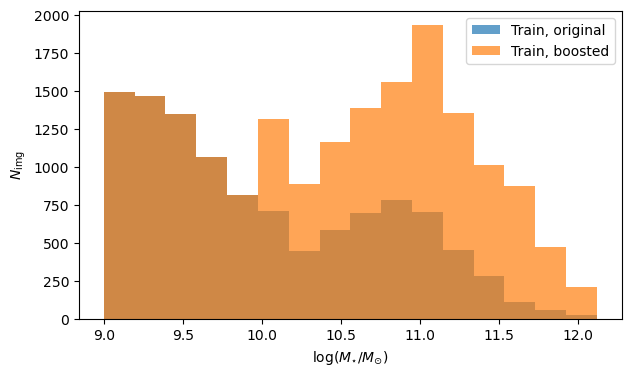

Seed 0: 11030 training galaxies -> 18352 boosted images; 1379 validation, 1379 test (not boosted)


In [8]:
xb = torch.from_numpy(X[:4].astype(np.float32)).to(device)

for family, make in [("Morlet", make_morlet), ("SHWS", make_shws)]:
    # extractor = make().to(device).eval()
    extractor = as_extractor(make())
    with torch.no_grad():
        out = extractor(xb)
    print(f"{family:7s} extractor output {tuple(out.shape)} -> {out.reshape(len(xb), -1).shape[1]} features per image")

print()
for name, build in NEURAL_BUILDERS.items():
    model = build().to(device).eval()
    with torch.no_grad():
        logits = model(xb)
    assert tuple(logits.shape) == (len(xb), 2), f"{name}: expected (4, 2) logits, got {tuple(logits.shape)}"
    total = sum(p.numel() for p in model.parameters())
    print(f"{name:24s} trainable {count_trainable(model):>10,d}   (all parameters incl. frozen: {total:,d})")
    for child_name, child in model.named_children():
        n = sum(p.numel() for p in child.parameters() if p.requires_grad)
        if n:
            print(f"    {child_name:20s} {n:>10,d}")
del model, extractor

# Effect of boosting on the first split (validation and test are not boosted)
d0 = get_seed_data(SEEDS[0])
log_m = lambda m: np.log10(m) + 10
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(log_m(Y_stellar_mass[d0["train_idx"]]), bins=16, alpha=0.7, label="Train, original")
ax.hist(log_m(Y_stellar_mass[d0["train_src"]]), bins=16, alpha=0.7, label="Train, boosted")
ax.set_xlabel(r"$\log(M_{\star} / M_{\odot})$")
ax.set_ylabel(r"$N_{\mathrm{img}}$")
ax.legend()
plt.show()
print(f"Seed {SEEDS[0]}: {len(d0['train_idx'])} training galaxies -> {len(d0['y_train'])} boosted images; "
      f"{len(d0['val_idx'])} validation, {len(d0['test_idx'])} test (not boosted)")
del d0

# Models

## Classical CNN

Instantiated model with 1153634 params.
[CNN] tuning lr=0.01: best val loss 0.6929 (epoch 11)
Instantiated model with 1153634 params.
[CNN] tuning lr=0.001: best val loss 0.5422 (epoch 14)
Instantiated model with 1153634 params.
[CNN] tuning lr=0.0001: best val loss 0.5732 (epoch 3)
[CNN] using lr=0.001
[CNN] seed 0: acc 0.7107, AUC 0.8009, restored epoch 14 (1s)
Instantiated model with 1153634 params.
[CNN] seed 1: acc 0.7331, AUC 0.8293, restored epoch 10 (33s)
Instantiated model with 1153634 params.
[CNN] seed 2: acc 0.7150, AUC 0.7921, restored epoch 17 (39s)
Instantiated model with 1153634 params.
[CNN] seed 3: acc 0.7404, AUC 0.8193, restored epoch 11 (34s)
Instantiated model with 1153634 params.
[CNN] seed 4: acc 0.7201, AUC 0.8028, restored epoch 13 (36s)

CNN: accuracy 0.7239 ± 0.0125, ROC-AUC 0.8089 ± 0.0151 over 5 seeds; 1,153,634 trainable parameters


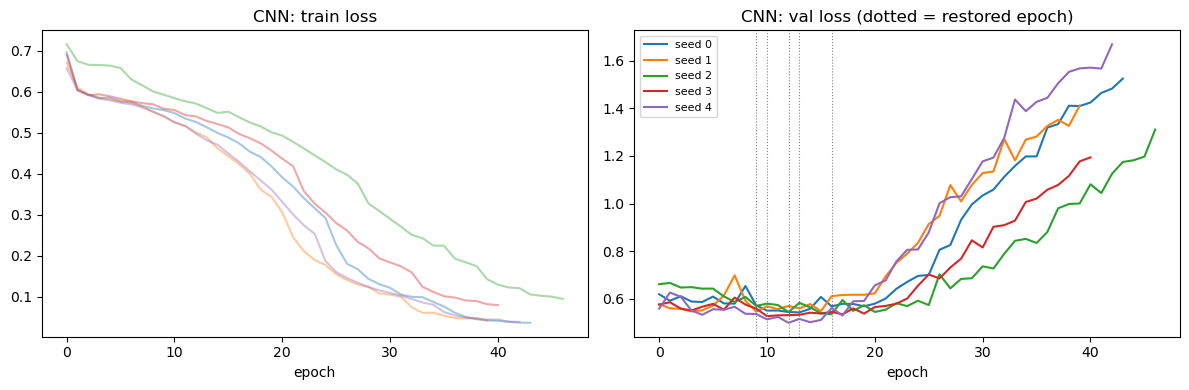

In [9]:
run_torch_experiment("CNN", build_cnn)

## Hybrid: Morlet + CNN (Oyallon)

243
2304
Instantiated model with 171560 params.
[Morlet + CNN (Oyallon)] tuning lr=0.01: best val loss 0.5400 (epoch 36)
243
2304
Instantiated model with 171560 params.
[Morlet + CNN (Oyallon)] tuning lr=0.001: best val loss 0.5352 (epoch 7)
243
2304
Instantiated model with 171560 params.
[Morlet + CNN (Oyallon)] tuning lr=0.0001: best val loss 0.5304 (epoch 9)
[Morlet + CNN (Oyallon)] using lr=0.0001
[Morlet + CNN (Oyallon)] seed 0: acc 0.7397, AUC 0.8227, restored epoch 9 (1s)
243
2304
Instantiated model with 171560 params.
[Morlet + CNN (Oyallon)] seed 1: acc 0.7273, AUC 0.8057, restored epoch 6 (167s)
243
2304
Instantiated model with 171560 params.
[Morlet + CNN (Oyallon)] seed 2: acc 0.7165, AUC 0.7960, restored epoch 7 (170s)
243
2304
Instantiated model with 171560 params.
[Morlet + CNN (Oyallon)] seed 3: acc 0.7491, AUC 0.8173, restored epoch 11 (184s)
243
2304
Instantiated model with 171560 params.
[Morlet + CNN (Oyallon)] seed 4: acc 0.7136, AUC 0.7919, restored epoch 9 (179s)

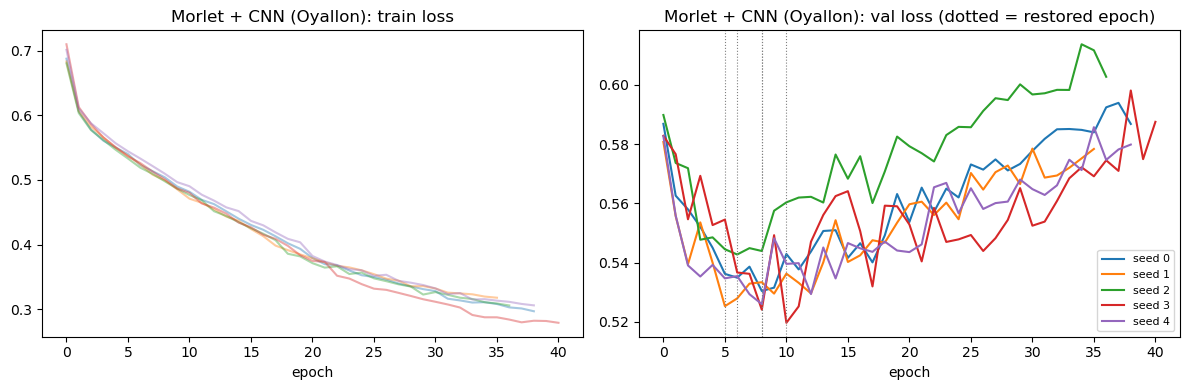

In [10]:
run_torch_experiment("Morlet + CNN (Oyallon)", build_oyallon)

## Solid Harm: SHWS + MLP

Instantiated model with 774622 params.
[SHWS + MLP] tuning lr=0.01: best val loss 0.4873 (epoch 31)
Instantiated model with 774622 params.
[SHWS + MLP] tuning lr=0.001: best val loss 0.4874 (epoch 41)
Instantiated model with 774622 params.
[SHWS + MLP] tuning lr=0.0001: best val loss 0.4817 (epoch 177)
[SHWS + MLP] using lr=0.0001
[SHWS + MLP] seed 0: acc 0.7491, AUC 0.8497, restored epoch 177 (1s)
Instantiated model with 774622 params.
[SHWS + MLP] seed 1: acc 0.7832, AUC 0.8676, restored epoch 198 (991s)
Instantiated model with 774622 params.
[SHWS + MLP] seed 2: acc 0.7578, AUC 0.8500, restored epoch 199 (987s)
Instantiated model with 774622 params.
[SHWS + MLP] seed 3: acc 0.7723, AUC 0.8634, restored epoch 197 (970s)
Instantiated model with 774622 params.
[SHWS + MLP] seed 4: acc 0.7397, AUC 0.8356, restored epoch 136 (721s)

SHWS + MLP: accuracy 0.7604 ± 0.0175, ROC-AUC 0.8533 ± 0.0127 over 5 seeds; 774,622 trainable parameters


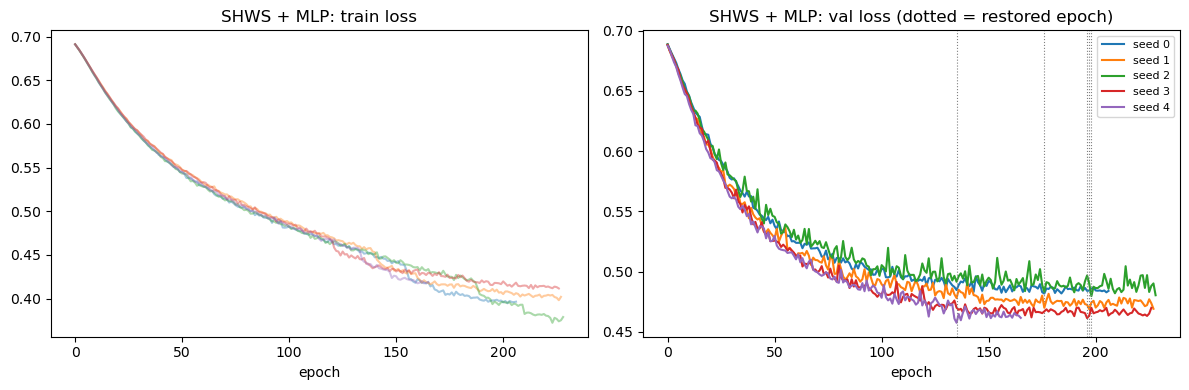

In [11]:
run_torch_experiment("SHWS + MLP", build_shws_mlp)

## Solid Harm Sklearn: SHWS + Linear

In [12]:
run_linear_experiment("SHWS + Linear", make_shws)

[SHWS + Linear] seed 0: 750 features, alpha=0.01 (val acc 0.7353), test acc 0.7382, AUC 0.8196 (4s)
[SHWS + Linear] seed 1: 750 features, alpha=0.001 (val acc 0.7404), test acc 0.7520, AUC 0.8332 (4s)
[SHWS + Linear] seed 2: 750 features, alpha=0.01 (val acc 0.7310), test acc 0.7324, AUC 0.8065 (4s)
[SHWS + Linear] seed 3: 750 features, alpha=0.0316 (val acc 0.7578), test acc 0.7302, AUC 0.8197 (4s)
[SHWS + Linear] seed 4: 750 features, alpha=0.316 (val acc 0.7498), test acc 0.7302, AUC 0.8241 (4s)

SHWS + Linear: accuracy 0.7366 ± 0.0092, ROC-AUC 0.8206 ± 0.0096 over 5 seeds; 751 trainable parameters


## Morlet MLP: Morlet + MLP

Instantiated model with 1251712 params.
[Morlet + MLP] tuning lr=0.01: best val loss 0.5245 (epoch 31)
Instantiated model with 1251712 params.
[Morlet + MLP] tuning lr=0.001: best val loss 0.5262 (epoch 31)
Instantiated model with 1251712 params.
[Morlet + MLP] tuning lr=0.0001: best val loss 0.5310 (epoch 132)
[Morlet + MLP] using lr=0.01
[Morlet + MLP] seed 0: acc 0.7382, AUC 0.8290, restored epoch 31 (1s)
Instantiated model with 1251712 params.
[Morlet + MLP] seed 1: acc 0.7310, AUC 0.8199, restored epoch 21 (223s)
Instantiated model with 1251712 params.
[Morlet + MLP] seed 2: acc 0.7281, AUC 0.8136, restored epoch 26 (244s)
Instantiated model with 1251712 params.
[Morlet + MLP] seed 3: acc 0.7397, AUC 0.8165, restored epoch 27 (247s)
Instantiated model with 1251712 params.
[Morlet + MLP] seed 4: acc 0.6998, AUC 0.7904, restored epoch 32 (271s)

Morlet + MLP: accuracy 0.7273 ± 0.0162, ROC-AUC 0.8139 ± 0.0143 over 5 seeds; 1,251,712 trainable parameters


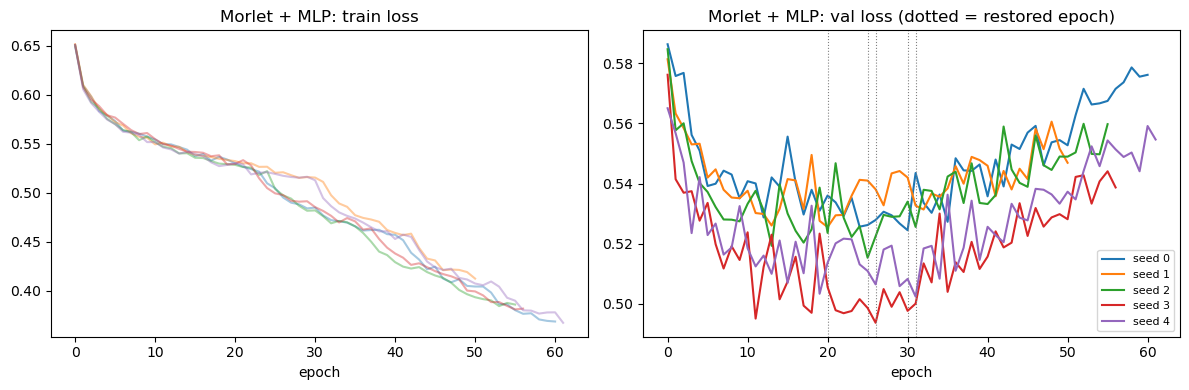

In [13]:
run_torch_experiment("Morlet + MLP", build_morlet_mlp)

## Morlet Sklearn: Morlet + Linear

In [14]:
run_linear_experiment("Morlet + Linear", make_morlet)

[Morlet + Linear] seed 0: 1215 features, alpha=100 (val acc 0.6831), test acc 0.6867, AUC 0.7491 (5s)
[Morlet + Linear] seed 1: 1215 features, alpha=10 (val acc 0.6809), test acc 0.7020, AUC 0.7740 (5s)
[Morlet + Linear] seed 2: 1215 features, alpha=31.6 (val acc 0.6904), test acc 0.6780, AUC 0.7475 (5s)
[Morlet + Linear] seed 3: 1215 features, alpha=0.316 (val acc 0.6795), test acc 0.6759, AUC 0.7463 (5s)
[Morlet + Linear] seed 4: 1215 features, alpha=100 (val acc 0.6983), test acc 0.6809, AUC 0.7420 (5s)

Morlet + Linear: accuracy 0.6847 ± 0.0105, ROC-AUC 0.7518 ± 0.0127 over 5 seeds; 1,216 trainable parameters


In [ ]:
from scripts.finetune_zoobot import train_zoobot_classifier
from models.zoobot.Zoobot import zoobot_classifier


def run_zoobot_experiment(name):
    RESULTS[name] = []
    for seed in SEEDS:
        t0 = time.time()
        set_seed(seed)
        data = get_seed_data(seed)
        # same augmentation object the other networks get from TorchDataset
        aug = TorchDataset(data["X_train"][:1], data["y_train"][:1], classification=True).augmentations if ONLINE_AUG else None
        probs = train_zoobot_classifier(
            data["X_train"], data["y_train"], data["X_val"], data["y_val"], data["X_test"],
            save_dir=f"zoobot_runs/{name.replace(' ', '_')}_seed{seed}", augmentations=aug,
            batch_size=BATCH_SIZE, max_epochs=MAX_EPOCHS, patience=EARLY_STOPPING)
        r = record(name, data, probs.argmax(1), probs[:, 1])
        print(f"[{name}] seed {seed}: acc {r['accuracy']:.4f}, AUC {r['roc_auc']:.4f} ({time.time() - t0:.0f}s)")
    params = sum(p.numel() for p in zoobot_classifier().parameters() if p.requires_grad)
    MODEL_INFO[name] = {"params": params, "lr": 1e-4}
    summarise(name)


run_zoobot_experiment("Zoobot + aug" if ONLINE_AUG else "Zoobot")

# Results

Mean ± s.d. over seeds. Significance against the best model (by mean accuracy) uses two tests:

* the **corrected resampled t-test** (Nadeau & Bengio, 2003) across seeds, which accounts for training sets overlapping between repeated random splits (a plain paired t-test is overconfident here);
* **McNemar's exact test** within each seed, on the paired test-set predictions.

In [15]:
MODEL_ORDER = ["CNN", "Morlet + CNN (Oyallon)", "Morlet + MLP", "Morlet + Linear", "SHWS + MLP", "SHWS + Linear",
               "Zoobot", "Zoobot + aug"]
METRICS = [("accuracy", "Accuracy"), ("roc_auc", "ROC-AUC"), ("precision", "Precision"),
           ("recall", "Recall"), ("f1", "F1")]

names = [n for n in MODEL_ORDER if len(RESULTS.get(n, [])) == len(SEEDS)]
missing = [n for n in MODEL_ORDER if n not in names]
if missing:
    print("Not run yet (or incomplete):", missing)
for n in names:
    assert [r["seed"] for r in RESULTS[n]] == list(SEEDS), f"{n}: seeds out of order"
    for r, ref in zip(RESULTS[n], RESULTS[names[0]]):
        assert np.array_equal(r["test_idx"], ref["test_idx"]), f"{n}: different test set for seed {r['seed']}"


def per_seed(name, key):
    return np.array([r[key] for r in RESULTS[name]], dtype=float)


def sd(v):
    return v.std(ddof=1) if len(v) > 1 else float("nan")


def corrected_resampled_ttest(a, b, n_train, n_test):
    """Nadeau & Bengio (2003) corrected resampled t-test for repeated random train/test splits."""
    d = np.asarray(a) - np.asarray(b)
    k = len(d)
    if k < 2:
        return float("nan")
    var = d.var(ddof=1)
    if var == 0:
        return 1.0 if d.mean() == 0 else 0.0
    t = d.mean() / np.sqrt((1 / k + n_test / n_train) * var)
    return 2 * stats.t.sf(abs(t), df=k - 1)


def mcnemar_exact(y_true, pred_a, pred_b):
    a_ok, b_ok = pred_a == y_true, pred_b == y_true
    n01, n10 = int(np.sum(a_ok & ~b_ok)), int(np.sum(~a_ok & b_ok))
    return 1.0 if n01 + n10 == 0 else stats.binomtest(min(n01, n10), n01 + n10, 0.5).pvalue


# ---- summary table ----
summary = pd.DataFrame(
    {lab: [f"{per_seed(n, k).mean():.4f} ± {sd(per_seed(n, k)):.4f}" for n in names] for k, lab in METRICS},
    index=names)
summary.insert(0, "Params", [f"{MODEL_INFO[n]['params']:,}" for n in names])
summary["Selected"] = [f"lr={MODEL_INFO[n]['lr']:g}" if "lr" in MODEL_INFO[n]
                       else "alpha=" + ", ".join(f"{a:.2g}" for a in MODEL_INFO[n]["alphas"]) for n in names]
display(summary)

# ---- significance against the best model ----
best = max(names, key=lambda n: per_seed(n, "accuracy").mean())
n_train = np.mean([r["n_train_galaxies"] for r in RESULTS[best]])
n_test = np.mean([len(r["test_idx"]) for r in RESULTS[best]])

sig_rows, p_vs_best = [], {}
for n in names:
    if n == best:
        continue
    diff = per_seed(best, "accuracy") - per_seed(n, "accuracy")
    p_t = corrected_resampled_ttest(per_seed(best, "accuracy"), per_seed(n, "accuracy"), n_train, n_test)
    p_mc = [mcnemar_exact(rb["y_true"], rb["y_pred"], rn["y_pred"]) for rb, rn in zip(RESULTS[best], RESULTS[n])]
    p_vs_best[n] = p_t
    sig_rows.append({"Model": n, "Δ accuracy (best − model)": f"{diff.mean():+.4f} ± {sd(diff):.4f}",
                     "corrected t-test p": f"{p_t:.3g}",
                     "McNemar p per seed": ", ".join(f"{p:.2g}" for p in p_mc),
                     "seeds with McNemar p<0.05": f"{sum(p < 0.05 for p in p_mc)}/{len(p_mc)}"})
print(f"Best mean accuracy: {best}")
display(pd.DataFrame(sig_rows).set_index("Model"))

# ---- LaTeX table ----
best_per_metric = {k: max(names, key=lambda n: per_seed(n, k).mean()) for k, _ in METRICS}


def tex_cell(name, key):
    v = per_seed(name, key)
    body = f"{v.mean():.3f} \\pm {sd(v):.3f}"
    return f"$\\mathbf{{{body}}}$" if best_per_metric[key] == name else f"${body}$"


split_kind = "galaxy-grouped" if GROUPS is not None else "stratified"
lines = [
    r"% Requires \usepackage{booktabs}",
    r"\begin{table}[htbp]",
    r"  \centering",
    (f"  \\caption{{Merger classification over {len(SEEDS)} random {split_kind} 80/10/10 splits "
     f"(mean $\\pm$ s.d.\\ over splits; about {int(round(n_test))} test galaxies per split). Within a split, "
     r"all models share the training set, mass-dependent D$_4$ boosting and test set. Precision and recall refer "
     r"to the merger class; F1 is class-weighted. $p$: corrected resampled $t$-test (Nadeau \& Bengio 2003) "
     f"on test accuracy against the best model ({best}).}}"),
    r"  \label{tab:merger-classification}",
    r"  \begin{tabular}{lrcccccc}",
    r"    \toprule",
    r"    Model & Params & Accuracy & ROC-AUC & Precision & Recall & F1 & $p$ \\",
    r"    \midrule",
]
for n in names:
    params = f"{MODEL_INFO[n]['params']:,}".replace(",", r"\,")
    p_txt = "--" if n == best else f"{p_vs_best[n]:.2g}"
    cells = " & ".join(tex_cell(n, k) for k, _ in METRICS)
    lines.append(f"    {n} & {params} & {cells} & {p_txt} \\\\")
lines += [r"    \bottomrule", r"  \end{tabular}", r"\end{table}"]
latex_table = "\n".join(lines)
print(latex_table)

os.makedirs("results", exist_ok=True)
with open("results/results_table.tex", "w") as f:
    f.write(latex_table + "\n")
config = {k: globals()[k] for k in ["SEEDS", "VAL_FRAC", "TEST_FRAC", "ONLINE_AUG", "BATCH_SIZE", "MAX_EPOCHS",
                                    "EARLY_STOPPING", "LR_PATIENCE", "LR_FACTOR", "MIN_LR", "WEIGHT_DECAY",
                                    "TUNE_LR", "LR_GRID", "RIDGE_ALPHAS", "MORLET_J", "MORLET_L", "LP_NORMS",
                                    "SHWS_CONFIG", "MLP_UNITS", "MLP_DROPOUT"]}
config["grouped_split"] = GROUPS is not None
with open("results/galaxy_classification_results.pkl", "wb") as f:
    pickle.dump({"results": RESULTS, "model_info": MODEL_INFO, "config": config}, f)
print("\nSaved results/results_table.tex and results/galaxy_classification_results.pkl")

,Params,Accuracy,ROC-AUC,Precision,Recall,F1,Selected
CNN,"1,153,634",0.7239 ± 0.0125,0.8089 ± 0.0151,0.7189 ± 0.0242,0.7278 ± 0.0513,0.7233 ± 0.0129,lr=0.001
Morlet + CNN (Oyallon),"171,560",0.7292 ± 0.0151,0.8067 ± 0.0133,0.7271 ± 0.0201,0.7239 ± 0.0126,0.7292 ± 0.0151,lr=0.0001
Morlet + MLP,"1,251,712",0.7273 ± 0.0162,0.8139 ± 0.0143,0.7254 ± 0.0229,0.7222 ± 0.0109,0.7273 ± 0.0162,lr=0.01
Morlet + Linear,"1,216",0.6847 ± 0.0105,0.7518 ± 0.0127,0.7004 ± 0.0142,0.6323 ± 0.0194,0.6837 ± 0.0105,"alpha=1e+02, 10, 32, 0.32, 1e+02"
SHWS + MLP,"774,622",0.7604 ± 0.0175,0.8533 ± 0.0127,0.7482 ± 0.0217,0.7768 ± 0.0203,0.7603 ± 0.0175,lr=0.0001
SHWS + Linear,751,0.7366 ± 0.0092,0.8206 ± 0.0096,0.7214 ± 0.0112,0.7606 ± 0.0078,0.7365 ± 0.0093,"alpha=0.01, 0.001, 0.01, 0.032, 0.32"


Best mean accuracy: SHWS + MLP


,Δ accuracy (best − model),corrected t-test p,McNemar p per seed,seeds with McNemar p<0.05
Model,,,,
CNN,+0.0365 ± 0.0116,0.00516,"0.0042, 0.0001, 0.00054, 0.0083, 0.14",4/5
Morlet + CNN (Oyallon),+0.0312 ± 0.0178,0.0375,"0.49, 1e-05, 0.00092, 0.082, 0.046",3/5
Morlet + MLP,+0.0331 ± 0.0151,0.0186,"0.39, 1.1e-05, 0.011, 0.003, 0.0017",4/5
Morlet + Linear,+0.0757 ± 0.0154,0.000983,"1.3e-05, 6.1e-10, 6.4e-09, 6.4e-12, 4.5e-05",5/5
SHWS + Linear,+0.0238 ± 0.0138,0.0392,"0.37, 0.0067, 0.027, 8.2e-05, 0.41",3/5


% Requires \usepackage{booktabs}
\begin{table}[htbp]
  \centering
  \caption{Merger classification over 5 random stratified 80/10/10 splits (mean $\pm$ s.d.\ over splits; about 1379 test galaxies per split). Within a split, all models share the training set, mass-dependent D$_4$ boosting and test set. Precision and recall refer to the merger class; F1 is class-weighted. $p$: corrected resampled $t$-test (Nadeau \& Bengio 2003) on test accuracy against the best model (SHWS + MLP).}
  \label{tab:merger-classification}
  \begin{tabular}{lrcccccc}
    \toprule
    Model & Params & Accuracy & ROC-AUC & Precision & Recall & F1 & $p$ \\
    \midrule
    CNN & 1\,153\,634 & $0.724 \pm 0.013$ & $0.809 \pm 0.015$ & $0.719 \pm 0.024$ & $0.728 \pm 0.051$ & $0.723 \pm 0.013$ & 0.0052 \\
    Morlet + CNN (Oyallon) & 171\,560 & $0.729 \pm 0.015$ & $0.807 \pm 0.013$ & $0.727 \pm 0.020$ & $0.724 \pm 0.013$ & $0.729 \pm 0.015$ & 0.037 \\
    Morlet + MLP & 1\,251\,712 & $0.727 \pm 0.016$ & $0.814 \pm 0.

## Performance by physical parameters

Accuracy as a function of stellar mass (all test galaxies), and merger recall as a function of merger mass ratio and time since merger (mergers only). Points are mean ± s.d. over seeds. Mass bins follow the boosting thresholds.

Accuracy vs stellar mass


,< 10,"[10, 10.5)","[10.5, 11)","[11, 11.5)",≥ 11.5
CNN,0.762 ± 0.018,0.808 ± 0.019,0.650 ± 0.030,0.558 ± 0.065,0.510 ± 0.078
Morlet + CNN (Oyallon),0.759 ± 0.012,0.826 ± 0.011,0.662 ± 0.039,0.575 ± 0.043,0.572 ± 0.072
Morlet + MLP,0.764 ± 0.018,0.806 ± 0.037,0.642 ± 0.028,0.605 ± 0.036,0.474 ± 0.082
Morlet + Linear,0.725 ± 0.016,0.756 ± 0.019,0.588 ± 0.052,0.547 ± 0.033,0.521 ± 0.045
SHWS + MLP,0.796 ± 0.019,0.845 ± 0.029,0.688 ± 0.033,0.608 ± 0.034,0.525 ± 0.085
SHWS + Linear,0.760 ± 0.005,0.848 ± 0.037,0.669 ± 0.033,0.598 ± 0.034,0.555 ± 0.164


Merger recall vs mass ratio


,< -0.488,"[-0.488, -0.328)","[-0.328, -0.118)",≥ -0.118
CNN,0.684 ± 0.066,0.666 ± 0.066,0.716 ± 0.052,0.840 ± 0.045
Morlet + CNN (Oyallon),0.647 ± 0.042,0.676 ± 0.026,0.740 ± 0.020,0.828 ± 0.026
Morlet + MLP,0.678 ± 0.041,0.666 ± 0.029,0.700 ± 0.028,0.840 ± 0.015
Morlet + Linear,0.536 ± 0.035,0.585 ± 0.028,0.599 ± 0.026,0.801 ± 0.021
SHWS + MLP,0.727 ± 0.052,0.722 ± 0.044,0.780 ± 0.015,0.875 ± 0.041
SHWS + Linear,0.718 ± 0.011,0.710 ± 0.015,0.755 ± 0.025,0.854 ± 0.038


Merger recall vs time since merger


,< 0.18,"[0.18, 0.199)","[0.199, 0.332)",≥ 0.332
CNN,0.751 ± 0.064,0.722 ± 0.064,0.720 ± 0.061,0.721 ± 0.035
Morlet + CNN (Oyallon),0.753 ± 0.034,0.729 ± 0.024,0.698 ± 0.046,0.715 ± 0.018
Morlet + MLP,0.749 ± 0.027,0.741 ± 0.013,0.699 ± 0.018,0.702 ± 0.018
Morlet + Linear,0.672 ± 0.041,0.594 ± 0.030,0.623 ± 0.034,0.643 ± 0.025
SHWS + MLP,0.789 ± 0.023,0.799 ± 0.038,0.772 ± 0.029,0.751 ± 0.023
SHWS + Linear,0.795 ± 0.018,0.771 ± 0.039,0.752 ± 0.020,0.729 ± 0.018


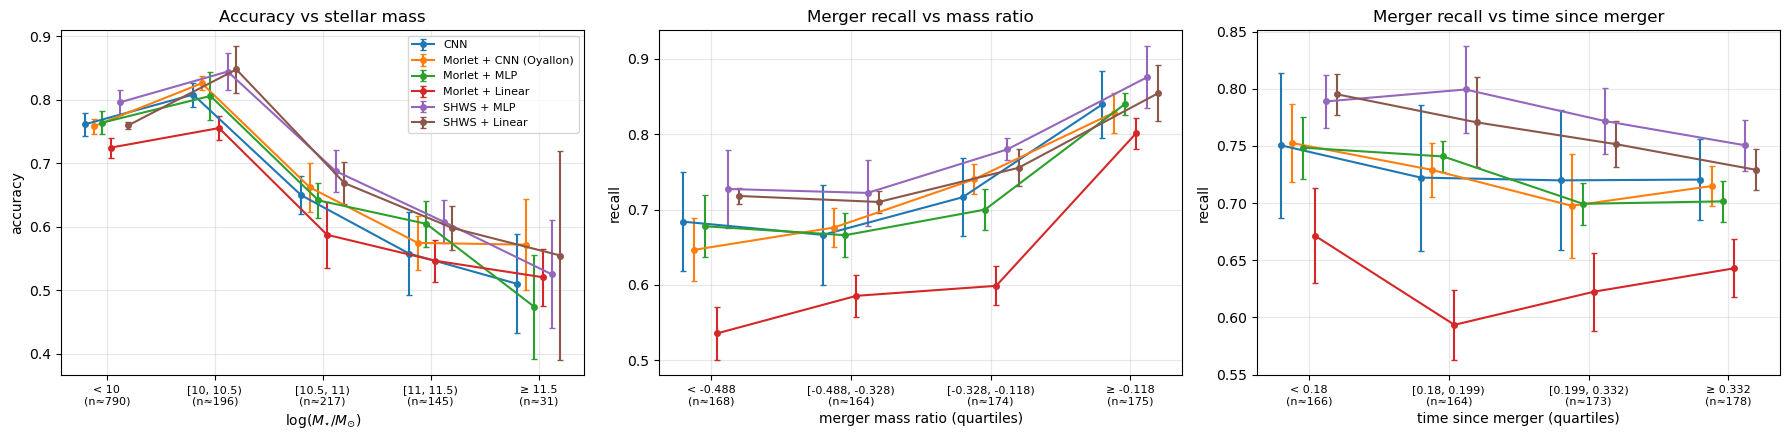

In [16]:
def binned_by_seed(name, values, edges, mergers_only=False):
    """Seeds x bins array of accuracy (or merger recall if mergers_only) within each bin of `values`."""
    out, counts = [], []
    for r in RESULTS[name]:
        v = values[r["test_idx"]]
        correct = r["y_pred"] == r["y_true"]
        mask = (r["y_true"] == 1) if mergers_only else np.ones_like(correct, dtype=bool)
        row, cnt = [], []
        for lo, hi in zip(edges[:-1], edges[1:]):
            sel = mask & (v >= lo) & (v < hi)
            row.append(correct[sel].mean() if sel.any() else np.nan)
            cnt.append(int(sel.sum()))
        out.append(row)
        counts.append(cnt)
    return np.array(out), np.mean(counts, axis=0)


def bin_labels(edges):
    labels = []
    for lo, hi in zip(edges[:-1], edges[1:]):
        if np.isinf(lo):
            labels.append(f"< {hi:.3g}")
        elif np.isinf(hi):
            labels.append(f"≥ {lo:.3g}")
        else:
            labels.append(f"[{lo:.3g}, {hi:.3g})")
    return labels


def quantile_edges(values, n_bins=4):
    q = np.nanquantile(values, np.linspace(0, 1, n_bins + 1))
    q[0], q[-1] = -np.inf, np.inf
    return np.unique(q)


is_merger = np.asarray(Y_is_merger).astype(bool)
panels = [
    ("Accuracy vs stellar mass", np.log10(Y_stellar_mass) + 10, np.array([-np.inf, 10, 10.5, 11, 11.5, np.inf]),
     False, r"$\log(M_{\star} / M_{\odot})$", "accuracy"),
    ("Merger recall vs mass ratio", np.asarray(Y_ratio, dtype=float), quantile_edges(np.asarray(Y_ratio, float)[is_merger]),
     True, "merger mass ratio (quartiles)", "recall"),
    ("Merger recall vs time since merger", np.asarray(Y_time, dtype=float), quantile_edges(np.asarray(Y_time, float)[is_merger]),
     True, "time since merger (quartiles)", "recall"),
]

fig, axes = plt.subplots(1, len(panels), figsize=(6 * len(panels), 4.5))
for ax, (title, values, edges, mergers_only, xlabel, ylabel) in zip(axes, panels):
    labels = bin_labels(edges)
    table = {}
    for j, n in enumerate(names):
        acc, counts = binned_by_seed(n, values, edges, mergers_only)
        x = np.arange(len(labels)) + (j - (len(names) - 1) / 2) * 0.08
        ax.errorbar(x, np.nanmean(acc, axis=0), yerr=np.nanstd(acc, axis=0, ddof=1) if len(SEEDS) > 1 else None,
                    fmt="o-", ms=4, capsize=2, label=n)
        table[n] = [f"{m:.3f} ± {s:.3f}" for m, s in zip(np.nanmean(acc, axis=0), np.nanstd(acc, axis=0, ddof=1))]
    ax.set_xticks(np.arange(len(labels)))
    ax.set_xticklabels([f"{l}\n(n≈{c:.0f})" for l, c in zip(labels, counts)], fontsize=8)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)
    print(title)
    display(pd.DataFrame(table, index=labels).T)
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

In [17]:
import inspect

shws = make_shws()
print(type(shws).__mro__)
print("public methods/attributes:")
print([a for a in dir(shws) if not a.startswith("_")])

print("\n--- ScatteringClassifier.__init__ / forward ---")
print(inspect.getsource(ScatteringClassifier.__init__))
print(inspect.getsource(ScatteringClassifier.forward))

(<class 'wavelets.solid_harmonic_model.SolidHarmonicModel'>, <class 'object'>)
public methods/attributes:
['M', 'N', 'bispectrum', 'device', 'higher_order', 'higher_order_filters', 'scatter', 'scattering', 'scattering_filters']

--- ScatteringClassifier.__init__ / forward ---
    def __init__(self, input_shape, scattering, reduced_units, dropout, output_type="regression"):
        super(ScatteringClassifier, self).__init__()

        dummy_input = torch.zeros(1, 3, input_shape[0], input_shape[1])
        dummy_output = scattering.scatter(dummy_input)
        self.scattering_dim = dummy_output.shape[-1]

        self.scattering = scattering

        self.model = nn.Sequential(
            nn.BatchNorm1d(self.scattering_dim),
            nn.Linear(self.scattering_dim, reduced_units),
            nn.BatchNorm1d(reduced_units),
            nn.Softmax(dim=1),
            nn.Dropout(p=dropout),
            nn.Linear(reduced_units, 1 if output_type == "regression" else 2),
        )

        